In [35]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 0.02)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

#-------------------------------
# DUSTY FSPS SPECTRUM
#-------------------------------
sp = fsps.StellarPopulation(zcontinuous=3, sfh=3, add_neb_emission=False, add_neb_continuum=False)

In [36]:
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)
wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 

# FSPS Dustfree

In [98]:
diffdust = 20
diffdust_index = -0.7
young_dust = 0
young_dust_index = -1

sp.params['dust2'] = 0
sp.params['dust1'] = 0
sp.params['dust_index'] = 1
sp.params['dust1_index'] = 1

wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 
print(sp.dust_mass)

0.0


# FSPS Diffuse Dust

In [99]:

sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4

wave, spec_fsps_diffuse = sp.get_spectrum(tage=13.8) 
print('FSPS with \ndust1:', sp.params['dust1'], '\ndust2:', sp.params['dust2'], '\ndust1_index:', sp.params['dust1_index'], '\ndust_index:', sp.params['dust_index'])

FSPS with 
dust1: 0.0 
dust2: 20 
dust1_index: -1 
dust_index: -0.7


# FSPS with Dust Emission

In [100]:
sp.params['add_dust_emission'] = True
sp.params['duste_umin'] = 1.0
sp.params['duste_qpah'] = 3.5
sp.params['duste_gamma'] = 1

wave, spec_fsps_hot_dust_emi = sp.get_spectrum(tage=13.8)
hot_mdust = sp.dust_mass

sp.params['add_dust_emission'] = True
sp.params['duste_umin'] = 1.0
sp.params['duste_qpah'] = 3.5
sp.params['duste_gamma'] = 0

wave, spec_fsps_cold_dust_emi = sp.get_spectrum(tage=13.8)
cold_mdust = sp.dust_mass


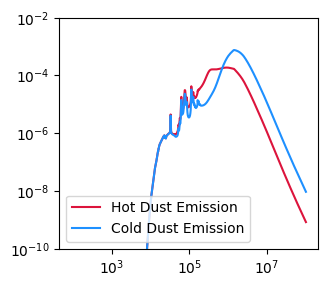

In [101]:
plt.figure(figsize = (10/3,3))
plt.loglog(wave, spec_fsps_hot_dust_emi, color = 'crimson', label='Hot Dust Emission')
plt.loglog(wave, spec_fsps_cold_dust_emi, color = 'dodgerblue', label='Cold Dust Emission')
plt.ylim(1e-10, 1e-2)
plt.legend()

# CSP 

In [102]:
dust_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}

emi_params = {'duste_qpah': 0.5, 
              'duste_umin': 1.0, 
              'duste_gamma': 0.01}
#-------------------------------
# CSP SPECTRUM WITH DUST
#-------------------------------
csp = CSPBasis(ssp_data, dusty=True, dust_params={'bin_edges': [(-jnp.inf, -1.97), (-1.97, 10)], 'laws': ['powerlaw', 'kriek_conroy']})
csp.add_sfh(sfr_bimodal, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)

print(csp.dust.get_default_fit_params())

spec_diffuse = csp.get_spectrum(dust_params=dust_params)

#-------------------------------
# CSP SPECTRUM WITHOUT DUST
#-------------------------------
spec_dustfree = csp.get_spectrum_dustfree()

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH
{'tau_pow': 1.0, 'alpha': 1.0, 'tau_kc': 1.0, 'dust_index': 0.0, 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}


# Compare Dustfree

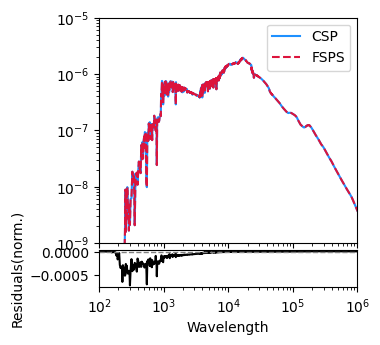

In [103]:
# Compute normalized residuals
residuals = (spec_dustfree - spec_fsps_dustfree) / spec_fsps_dustfree

# Create subplots
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10/3, 3.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 0.5], 'hspace': 0.05})

ax0.loglog(wave, spec_dustfree, color='dodgerblue', label='CSP')
ax0.loglog(wave, spec_fsps_dustfree, color='crimson', linestyle='dashed', label='FSPS')
ax0.set_ylim(1e-9, 1e-5)
ax0.set_xlim(1e2, 1e6)
ax0.legend()

ax1.plot(wave, residuals, color='black')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_xlabel('Wavelength')
ax1.set_ylabel('Residuals(norm.)')
ax1.set_yscale('linear')

# Compare Dust Attenuation

/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_26397/737656043.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


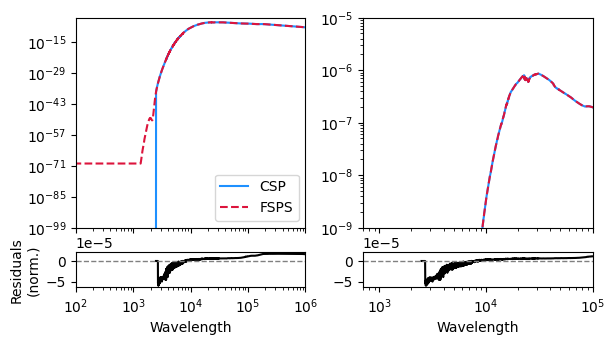

In [104]:
residuals = (spec_diffuse - spec_fsps_diffuse) / spec_fsps_diffuse

fig, axs = plt.subplots(2, 2, figsize=(20/3, 3.5), sharex='col',
                        gridspec_kw={'height_ratios': [3, 0.5], 'hspace': 0.2, 'wspace': 0.25})

ax0_left, ax1_left = axs[0, 0], axs[1, 0]
ax0_left.loglog(wave, spec_diffuse, color='dodgerblue', label='CSP')
ax0_left.loglog(wave, spec_fsps_diffuse, color='crimson', linestyle='dashed', label='FSPS')
ax0_left.set_ylim(1e-99, 1e-4)
ax0_left.set_xlim(1e2, 1e6)
ax0_left.legend()

ax1_left.plot(wave, residuals, color='black')
ax1_left.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1_left.set_xlabel('Wavelength')
ax1_left.set_ylabel('Residuals\n(norm.)')

ax0_right, ax1_right = axs[0, 1], axs[1, 1]
ax0_right.loglog(wave, spec_diffuse, color='dodgerblue', label='CSP')
ax0_right.loglog(wave, spec_fsps_diffuse, color='crimson', linestyle='dashed', label='FSPS')
ax0_right.set_ylim(1e-9, 1e-5)
ax0_right.set_xlim(7*1e2, 1e5)

ax1_right.plot(wave, residuals, color='black')
ax1_right.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1_right.set_xlabel('Wavelength')

plt.tight_layout()
plt.show()

# Get Attenuation Curve via Spectra

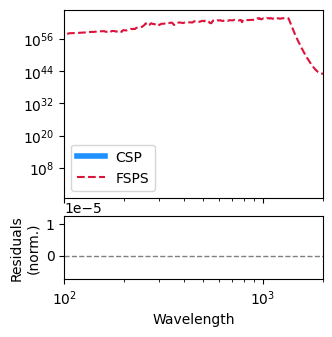

In [105]:
csp_ratio = spec_dustfree / spec_diffuse
fsps_ratio = spec_fsps_dustfree / spec_fsps_diffuse

residuals = csp_ratio / fsps_ratio - 1

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10/3, 3.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.15})

ax0.loglog(csp.wave, csp_ratio, lw=4, color='dodgerblue', label='CSP')
ax0.loglog(wave, fsps_ratio, color='crimson', linestyle='dashed', label='FSPS')
ax0.set_xlim(1e2, 2*1e3)
ax0.legend()
ax0.tick_params(labelbottom=False)

ax1.plot(wave, residuals, color='black')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.set_xlabel('Wavelength')
ax1.set_ylabel('Residuals\n(norm.)')


plt.show()

# Add Dust Emission - pure Python no JAX

## Read in Emission Grid

In [106]:
import numpy as np
from pathlib import Path

def read_dustem_files(sps_home, str_dustem, nqpah_dustem, ndim_dustem, spec_lambda, numin_dustem):
    # Allocate arrays
    dustem2_dustem = np.zeros((len(spec_lambda), nqpah_dustem, numin_dustem * 2))
    
    for sqpah in range(nqpah_dustem):

        # Build file path
        if sqpah == 10:
            filename = Path(sps_home) / 'dust' / 'dustem' / f"{str_dustem}_MW3.1_100.dat"
        else:
            filename = Path(sps_home) / 'dust' / 'dustem' / f"{str_dustem}_MW3.1_{sqpah}0.dat"
        print('filename:', filename)
        # Read file
        try:
            with open(filename, 'r') as f:
                lines = f.readlines()
        except FileNotFoundError:
            raise RuntimeError("SPS_SETUP ERROR: error opening dust emission file")
        
        # Skip 2 header lines
        data_lines = lines[2:2 + ndim_dustem]


        # Parse wavelength and dust emission spectrum
        lambda_dustem = np.zeros(ndim_dustem)
        dustem_dustem = np.zeros((ndim_dustem, numin_dustem * 2))
        
        for i, line in enumerate(data_lines):
            try:
                parts = list(map(float, line.strip().split()))
                lambda_dustem[i] = parts[0]
                dustem_dustem[i, :] = parts[1:]
            except Exception:
                raise RuntimeError("SPS_SETUP ERROR: error during dust emission read")
        
        # Convert wavelength from microns to Angstroms
        lambda_dustem *= 1e4

        # Interpolate dust spectrum to master wavelength grid
        for j in range(numin_dustem * 2):
            # Only interpolate for wavelengths >= 1 micron (1e4 Angstroms)
            mask = spec_lambda >= 1e4
            if np.any(mask):
                dustem2_dustem[mask, sqpah, j] = np.interp(
                    spec_lambda[mask], lambda_dustem, dustem_dustem[:, j]
                )

    return dustem2_dustem

dustem2_dustem = read_dustem_files('/Users/amanda/Prospector/fsps', str_dustem='dl07', nqpah_dustem=7, ndim_dustem=1001, spec_lambda=csp.wave, 
                                   numin_dustem=22)

filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_00.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_10.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_20.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_30.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_40.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_50.dat
filename: /Users/amanda/Prospector/fsps/dust/dustem/dl07_MW3.1_60.dat


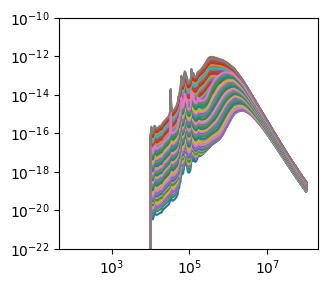

In [107]:
plt.figure(figsize = (10/3,3))
for sqpah in range(7):
    for j in range(44):
        plt.loglog(csp.wave, dustem2_dustem[:, sqpah, j], label=f'PAH {sqpah}, j={j}')
    plt.ylim(1e-22, 1e-10)


Dust emission parameters from FSPS:
  qPAH: 3.5
  Umin: 1.0
  Gamma: 0
Lbol before attenuation: -2469577500.0
Lbol after attenuation: -97148904.0
lbold: -2366763000.0
lboln: -2372428544.0
[0.000000e+00 0.000000e+00 0.000000e+00 ... 9.815982e-09 9.556133e-09
 9.309609e-09]
lbold: -5652006.5
lboln: -5665535.999999999
[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 9.8394235e-09 9.5789536e-09
 9.3318411e-09]
lbold: -13497.19
lboln: -13529.499999999069
[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 9.8394795e-09 9.5790078e-09
 9.3318944e-09]
Dust self-absorption iteration: 3
-8.574542e-05


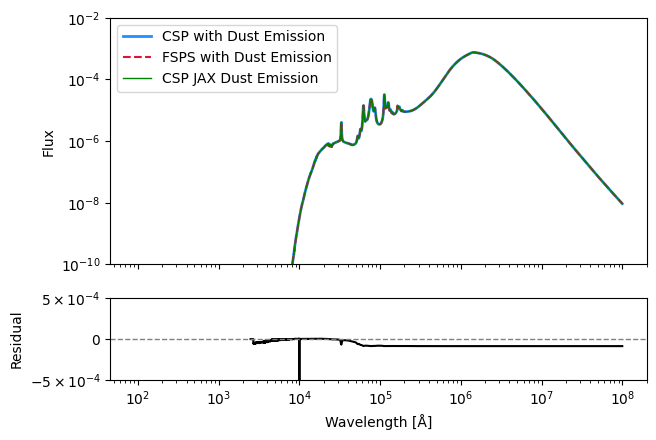

In [140]:
iself = 0


duste_qpah = sp.params['duste_qpah']
duste_umin = sp.params['duste_umin']
duste_gamma = sp.params['duste_gamma']

print('Dust emission parameters from FSPS:')
print('  qPAH:', duste_qpah)
print('  Umin:', duste_umin)
print('  Gamma:', duste_gamma)

diff_dust = spec_diffuse / spec_dustfree

# Constants
clight = const.c.value # speed of light in m/s
tiny_number = 1e-70     # small floor value to avoid division by zero
mypi = np.pi
spec_lambda = csp.wave  # assuming csp.wave is in Angstroms



specdust = spec_diffuse.copy()
specdustfree = spec_dustfree.copy()

qpaharr = np.array([0.47,1.12,1.77,2.50,3.19,3.90,4.58])
nqpah_dustem = len(qpaharr)
uminarr = np.array([0.1,0.15,0.2,0.3,0.4,0.5,0.7,0.8,1.0,1.2,1.5,2.0,2.5,3.0,4.0,5.0,7.0,8.0,12.0,15.0,20.0,25.0])
numin_dustem = len(uminarr)
# Compute nu = c / lambda, where lambda is in Angstroms
nu = clight * 1e10 / spec_lambda  # assuming spec_lambda is in Angstroms

# Compute total bolometric luminosity before and after attenuation
lbold = np.trapezoid(specdust, nu)  # TSUM is assumed to be a trapezoidal integral
lboln = np.trapezoid((specdustfree), nu)

print('Lbol before attenuation:', lboln)
print('Lbol after attenuation:', lbold)

# --- QPAH interpolation ---
qlo = max(min(np.searchsorted(qpaharr, duste_qpah) - 1, nqpah_dustem - 2), 0)
dq = (duste_qpah - qpaharr[qlo]) / (qpaharr[qlo + 1] - qpaharr[qlo])
dq = min(max(dq, 0.0), 1.0)

# --- Umin interpolation ---
ulo = max(min(np.searchsorted(uminarr, duste_umin) - 1, numin_dustem - 1), 0)
du = (duste_umin - uminarr[ulo]) / (uminarr[ulo + 1] - uminarr[ulo])
du = min(max(du, 0.0), 1.0)

# --- gamma limiting ---
gamma = max(min(duste_gamma, 1.0), 0.0)

# --- bilinear interpolation ---
# Remember: Python uses 0-based indexing
dumin = (
    (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo] +
    dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo] +
    dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1)] +
    (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1)]
)

dumax = (
    (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo + 1] +
    dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo + 1] +
    dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1) + 1] +
    (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1) + 1]
)

# Combine both parts of P(U) dU
mduste = (1 - gamma) * dumin + gamma * dumax
mduste = np.maximum(mduste, tiny_number)

# Normalize the dust emission to match the absorbed luminosity
labs = lboln - lbold
norm = np.trapezoid(mduste, nu)
duste = mduste / norm * labs
duste = np.maximum(duste, tiny_number)

# --- Include dust self-absorption iteratively ---
tduste = np.zeros_like(duste)
counter = 0

dustearr = []
while (abs(lboln - lbold) > 1e-2) and  (counter < 3):
    oduste = duste.copy()
    duste = duste * diff_dust  # apply dust self-absorption curve
    tduste += duste

    lbold = np.trapezoid(duste, nu)     # after absorption
    lboln = np.trapezoid(oduste, nu)    # before absorption

    duste = np.maximum(mduste / norm * (lboln - lbold), tiny_number)
    dustearr.append(tduste)
    counter += 1
    print('lbold:', lbold)
    print('lboln:', lboln)
    print(tduste)

print('Dust self-absorption iteration:', counter)

# Compute final dust mass
mdust = 3.21e-3 / (4 * mypi) * labs / norm

# Add dust emission to original dust spectrum
specdust += tduste

# Debug call (replace with real function if needed)
# dust_debug_set(nspec, mduste, tduste, duste, specdust, labs, norm, mdust)

# If nebemlineinspec ≠ 0
# (in Fortran this was inside the ELSE branch)



# Compute normalized residuals
residuals = (specdust - spec_fsps_cold_dust_emi) / spec_fsps_cold_dust_emi

# Create figure with two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3, 4.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Top panel: spectra
ax1.loglog(csp.wave, specdust, color='dodgerblue', lw = 2, label='CSP with Dust Emission')
ax1.loglog(csp.wave, spec_fsps_cold_dust_emi, ls = 'dashed', color='crimson', label='FSPS with Dust Emission')
ax1.loglog(csp.wave, specdust_jax, color='green', lw=1, label='CSP JAX Dust Emission')
ax1.set_ylim(1e-10, 1e-2)

ax1.set_ylabel("Flux")
ax1.legend()

# Bottom panel: normalized residuals
ax2.plot(csp.wave, residuals, color='black')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.set_yscale('symlog')
ax2.set_ylabel("Residual")
ax2.set_xlabel("Wavelength [Å]")
ax2.set_ylim(-0.5*1e-3, 0.5*1e-3)

plt.tight_layout()
print(residuals[-1])


In [148]:
diffdust

20

# Add Dust Emission

Dust emission parameters from FSPS:
  qPAH: 3.5
  Umin: 1.0
  Gamma: 0
Lbol before attenuation: -2469577500.0
Lbol after attenuation: -97148904.0

qlo: 4, dq: 0.43661971830985924, ulo: 7, du: 1.0
gamma: 0
mduste: 1.5523706526182374e-12
dumin: 1.5523706526182374e-12
dumax: 9.148576956609085e-12
labs: -2372428500.0
norm: -0.035607123969918705
duste sum: 0.1034312248933882
lbold: -2366763000.0
lboln: -2372428544.0
[0.000000e+00 0.000000e+00 0.000000e+00 ... 9.815982e-09 9.556133e-09
 9.309609e-09]
lbold: -5652006.5
lboln: -5665535.999999999
[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 9.8394235e-09 9.5789536e-09
 9.3318411e-09]
Dust self-absorption iteration: 2
-9.145543e-05


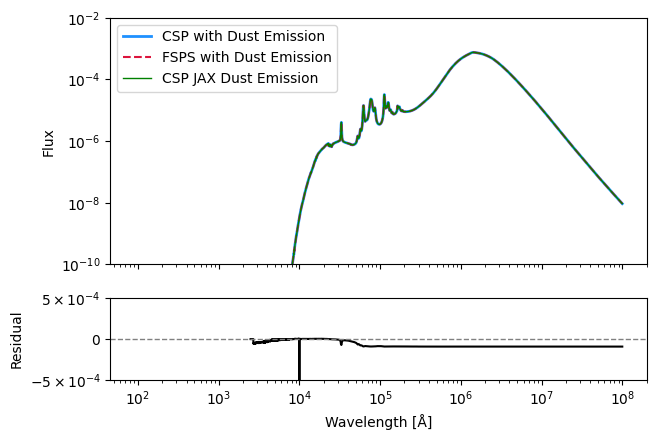

In [155]:
iself = 0


duste_qpah = sp.params['duste_qpah']
duste_umin = sp.params['duste_umin']
duste_gamma = sp.params['duste_gamma']

print('Dust emission parameters from FSPS:')
print('  qPAH:', duste_qpah)
print('  Umin:', duste_umin)
print('  Gamma:', duste_gamma)

diff_dust = spec_diffuse / spec_dustfree

# Constants
clight = const.c.value # speed of light in m/s
tiny_number = 1e-70     # small floor value to avoid division by zero
mypi = np.pi
spec_lambda = csp.wave  # assuming csp.wave is in Angstroms



specdust = spec_diffuse.copy()
specdustfree = spec_dustfree.copy()

qpaharr = np.array([0.47,1.12,1.77,2.50,3.19,3.90,4.58])
nqpah_dustem = len(qpaharr)
uminarr = np.array([0.1,0.15,0.2,0.3,0.4,0.5,0.7,0.8,1.0,1.2,1.5,2.0,2.5,3.0,4.0,5.0,7.0,8.0,12.0,15.0,20.0,25.0])
numin_dustem = len(uminarr)
# Compute nu = c / lambda, where lambda is in Angstroms
nu = clight * 1e10 / spec_lambda  # assuming spec_lambda is in Angstroms

# Compute total bolometric luminosity before and after attenuation
lbold = np.trapezoid(specdust, nu)  # TSUM is assumed to be a trapezoidal integral
lboln = np.trapezoid(specdustfree, nu)

print('Lbol before attenuation:', lboln)
print('Lbol after attenuation:', lbold)

# --- QPAH interpolation ---
qlo = max(min(np.searchsorted(qpaharr, duste_qpah) - 1, nqpah_dustem - 2), 0)
dq = (duste_qpah - qpaharr[qlo]) / (qpaharr[qlo + 1] - qpaharr[qlo])
dq = min(max(dq, 0.0), 1.0)

# --- Umin interpolation ---
ulo = max(min(np.searchsorted(uminarr, duste_umin) - 1, numin_dustem - 1), 0)
du = (duste_umin - uminarr[ulo]) / (uminarr[ulo + 1] - uminarr[ulo])
du = min(max(du, 0.0), 1.0)

print(f"\nqlo: {qlo}, dq: {dq}, ulo: {ulo}, du: {du}")

# --- gamma limiting ---
gamma = max(min(duste_gamma, 1.0), 0.0)

# --- bilinear interpolation ---
# Remember: Python uses 0-based indexing
dumin = (
    (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo] +
    dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo] +
    dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1)] +
    (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1)]
)

dumax = (
    (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo + 1] +
    dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo + 1] +
    dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1) + 1] +
    (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1) + 1]
)

# Combine both parts of P(U) dU
mduste = (1 - gamma) * dumin + gamma * dumax
mduste = np.maximum(mduste, tiny_number)


print('gamma:', gamma)
print('mduste:', np.sum(mduste))
print('dumin:', np.sum(dumin))
print('dumax:', np.sum(dumax))

# Normalize the dust emission to match the absorbed luminosity
labs = lboln - lbold
norm = np.trapezoid(mduste, nu)
duste = mduste / norm * labs
duste = np.maximum(duste, tiny_number)

print('labs:', labs)
print('norm:', norm)
print('duste sum:', np.sum(duste))

# --- Include dust self-absorption iteratively ---
tduste = np.zeros_like(duste)
counter = 0

dustearr = []
while (abs(lboln - lbold) > 1e-2) and  (counter < 2):
    oduste = duste.copy()
    duste = duste * diff_dust  # apply dust self-absorption curve
    tduste += duste

    lbold = np.trapezoid(duste, nu)     # after absorption
    lboln = np.trapezoid(oduste, nu)    # before absorption

    duste = np.maximum(mduste / norm * (lboln - lbold), tiny_number)
    dustearr.append(tduste)
    counter += 1
    print('lbold:', lbold)
    print('lboln:', lboln)
    print(tduste)

print('Dust self-absorption iteration:', counter)

# Compute final dust mass
mdust = 3.21e-3 / (4 * mypi) * labs / norm

# Add dust emission to original dust spectrum
specdust += tduste

# Debug call (replace with real function if needed)
# dust_debug_set(nspec, mduste, tduste, duste, specdust, labs, norm, mdust)

# If nebemlineinspec ≠ 0
# (in Fortran this was inside the ELSE branch)



# Compute normalized residuals
residuals = (specdust - spec_fsps_cold_dust_emi) / spec_fsps_cold_dust_emi

# Create figure with two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3, 4.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Top panel: spectra
ax1.loglog(csp.wave, specdust, color='dodgerblue', lw = 2, label='CSP with Dust Emission')
ax1.loglog(csp.wave, spec_fsps_cold_dust_emi, ls = 'dashed', color='crimson', label='FSPS with Dust Emission')
ax1.loglog(csp.wave, specdust_jax, color='green', lw=1, label='CSP JAX Dust Emission')
ax1.set_ylim(1e-10, 1e-2)

ax1.set_ylabel("Flux")
ax1.legend()

# Bottom panel: normalized residuals
ax2.plot(csp.wave, residuals, color='black')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.set_yscale('symlog')
ax2.set_ylabel("Residual")
ax2.set_xlabel("Wavelength [Å]")
ax2.set_ylim(-0.5*1e-3, 0.5*1e-3)

plt.tight_layout()
print(residuals[-1])


In [146]:
np.trapezoid(spec_diffuse, nu)

np.float32(-97148904.0)

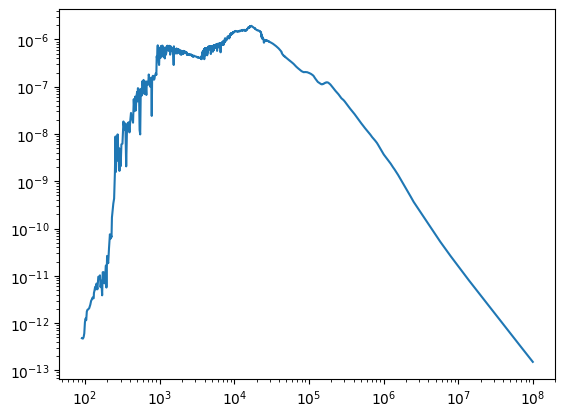

In [156]:
plt.loglog(csp.wave, specdustfree)

import pickle as pkl

with open('dust_emission_debug.pkl', 'wb') as f:
    pkl.dump({
        'specdust': specdust,
        'specdustfree': specdustfree,
        'spec_diffuse': spec_diffuse,
        'spec_fsps_diffuse': spec_fsps_diffuse,
        'spec_fsps_cold_dust_emi': spec_fsps_cold_dust_emi,
        'tduste': tduste,
        'duste': duste,
        'labs': labs,
        'norm': norm,
        'mdust': mdust,
        'nu': nu,
        'diff_curve': diff_dust
    }, f)

In [132]:
def compute_dust_emission_jax(sp, csp_wave, spec_diffuse, spec_dustfree, dustem2_dustem):
    """Compute dust emission with 2 explicit self-absorption iterations using JAX."""

    # Extract parameters
    duste_qpah = sp.params['duste_qpah']
    duste_umin = sp.params['duste_umin']
    duste_gamma = sp.params['duste_gamma']

    # Precompute arrays
    diff_dust = spec_diffuse / spec_dustfree
    clight = const.c.value  # m/s
    tiny_number = 1e-70
    mypi = jnp.pi

    spec_lambda = csp_wave  # Angstrom
    nu = clight * 1e10 / spec_lambda  # Hz

    specdust = spec_diffuse
    specdustfree = spec_dustfree

    # --- Base grids ---
    qpaharr = jnp.array([0.47, 1.12, 1.77, 2.50, 3.19, 3.90, 4.58])
    uminarr = jnp.array([0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 0.8, 1.0, 1.2,
                         1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0, 8.0, 12.0, 15.0, 20.0, 25.0])
    nqpah_dustem = qpaharr.size
    numin_dustem = uminarr.size

    # --- Compute Lbol before and after attenuation ---
    lbold =jnp.trapezoid(specdust, nu)
    lboln =jnp.trapezoid(spec_dustfree, nu)

    print('Lbol before attenuation:', lboln)
    print('Lbol after attenuation:', lbold)

    # --- QPAH interpolation setup ---
    qlo = jnp.clip(jnp.searchsorted(qpaharr, duste_qpah) - 1, 0, nqpah_dustem - 2)
    dq = (duste_qpah - qpaharr[qlo]) / (qpaharr[qlo + 1] - qpaharr[qlo])
    dq = jnp.clip(dq, 0.0, 1.0)

    # --- Umin interpolation setup ---
    ulo = jnp.clip(jnp.searchsorted(uminarr, duste_umin) - 1, 0, numin_dustem - 2)
    du = (duste_umin - uminarr[ulo]) / (uminarr[ulo + 1] - uminarr[ulo])
    du = jnp.clip(du, 0.0, 1.0)

    # --- gamma limiting ---
    gamma = jnp.clip(duste_gamma, 0.0, 1.0)

    # --- Bilinear interpolation ---
    dumin = (
        (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo] +
        dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo] +
        dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1)] +
        (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1)]
    )

    dumax = (
        (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo + 1] +
        dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo + 1] +
        dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1) + 1] +
        (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1) + 1]
    )

    # Combine both parts of P(U)dU
    mduste = (1 - gamma) * dumin + gamma * dumax
    mduste = jnp.maximum(mduste, tiny_number)

    # Normalize the dust emission to match the absorbed luminosity
    labs = lboln - lbold
    norm =jnp.trapezoid(mduste, nu)
    duste = mduste / norm * labs
    duste = jnp.maximum(duste, tiny_number)

    # --- Two explicit self-absorption iterations ---
    # Iteration 1
    oduste_1 = duste
    duste_1 = duste * diff_dust
    tduste_1 = duste_1
    lbold_1 =jnp.trapezoid(duste_1, nu)
    lboln_1 =jnp.trapezoid(oduste_1, nu)
    duste_1 = jnp.maximum(mduste / norm * (lboln_1 - lbold_1), tiny_number)

    # Iteration 2
    oduste_2 = duste_1
    duste_2 = duste_1 * diff_dust
    tduste_2 = tduste_1 + duste_2
    lbold_2 =jnp.trapezoid(duste_2, nu)
    lboln_2 =jnp.trapezoid(oduste_2, nu)
    duste_2 = jnp.maximum(mduste / norm * (lboln_2 - lbold_2), tiny_number)

    # Final results
    tduste = tduste_2
    specdust_final = specdust + tduste

    # Dust mass
    mdust = 3.21e-3 / (4 * mypi) * labs / norm

    return specdust_final, mdust, tduste

In [157]:
sp.zlegend

array([4.49043431e-05, 1.42000001e-04, 2.52515678e-04, 4.49043431e-04,
       7.98524687e-04, 1.42000001e-03, 2.52515678e-03, 4.49043431e-03,
       7.98524687e-03, 1.42000001e-02, 2.52515678e-02, 4.49043431e-02])

-8.574542e-05


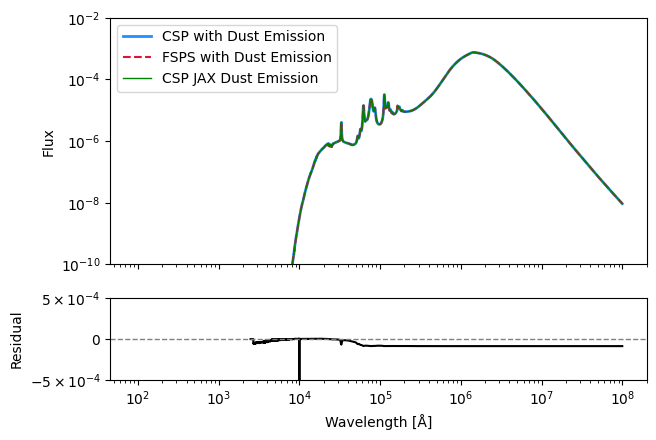

# After how mnay loops to the residuals converge?

In [133]:
import numpy as np
from astropy import constants as const

def compute_dust_emission( duste_gamma,
    csp_wave,
    spec_diffuse,
    spec_dustfree,
    dustem2_dustem,
    spec_fsps_emission=None,
    max_iter=20,
    stop_tol=1e-2,
    return_residual=False,
):
    # Setup
    iself = 0
    duste_qpah = sp.params['duste_qpah']
    duste_umin = sp.params['duste_umin']
    
    diff_dust = spec_diffuse / spec_dustfree
    clight = const.c.value  # m/s
    tiny_number = 1e-70
    mypi = np.pi
    spec_lambda = csp_wave
    specdust = spec_diffuse.copy()
    specdustfree = spec_dustfree.copy()
    nu = clight * 1e10 / spec_lambda  # Hz

    # Grids
    qpaharr = np.array([0.47, 1.12, 1.77, 2.50, 3.19, 3.90, 4.58])
    uminarr = np.array([0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 0.8, 1.0,
                        1.2, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0, 8.0,
                        12.0, 15.0, 20.0, 25.0])
    nqpah_dustem = len(qpaharr)
    numin_dustem = len(uminarr)

    # Bolometric luminosities
    lbold = np.trapezoid(specdust, nu)
    lboln = np.trapezoid(specdustfree, nu)

    # QPAH interpolation
    qlo = max(min(np.searchsorted(qpaharr, duste_qpah) - 1, nqpah_dustem - 2), 0)
    dq = (duste_qpah - qpaharr[qlo]) / (qpaharr[qlo + 1] - qpaharr[qlo])
    dq = min(max(dq, 0.0), 1.0)

    # Umin interpolation
    ulo = max(min(np.searchsorted(uminarr, duste_umin) - 1, numin_dustem - 2), 0)
    du = (duste_umin - uminarr[ulo]) / (uminarr[ulo + 1] - uminarr[ulo])
    du = min(max(du, 0.0), 1.0)

    # gamma
    gamma = max(min(duste_gamma, 1.0), 0.0)

    # Bilinear interpolation
    dumin = (
        (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo] +
        dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo] +
        dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1)] +
        (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1)]
    )
    dumax = (
        (1 - dq) * (1 - du) * dustem2_dustem[:, qlo, 2 * ulo + 1] +
        dq * (1 - du) * dustem2_dustem[:, qlo + 1, 2 * ulo + 1] +
        dq * du * dustem2_dustem[:, qlo + 1, 2 * (ulo + 1) + 1] +
        (1 - dq) * du * dustem2_dustem[:, qlo, 2 * (ulo + 1) + 1]
    )

    mduste = (1 - gamma) * dumin + gamma * dumax
    mduste = np.maximum(mduste, tiny_number)

    labs = lboln - lbold
    norm = np.trapezoid(mduste, nu)
    duste = mduste / norm * labs
    duste = np.maximum(duste, tiny_number)

    # Self-absorption loop
    tduste = np.zeros_like(duste)
    counter = 0

    while abs(lboln - lbold) > stop_tol and counter < max_iter:
        oduste = duste.copy()
        duste = duste * diff_dust
        tduste += duste

        lbold = np.trapezoid(duste, nu)
        lboln = np.trapezoid(oduste, nu)

        duste = np.maximum(mduste / norm * (lboln - lbold), tiny_number)
        counter += 1


    mdust = 3.21e-3 / (4 * mypi) * labs / norm
    specdust += tduste


    residual = (specdust - spec_fsps_emission) / spec_fsps_emission

    return specdust, mdust, residual[-1]


max_iter: 1 residual: -0.0026261553
max_iter: 2 residual: -9.218787e-05
max_iter: 3 residual: -8.572673e-05
max_iter: 4 residual: -8.572673e-05
max_iter: 5 residual: -8.572673e-05
max_iter: 6 residual: -8.572673e-05
max_iter: 7 residual: -8.572673e-05
max_iter: 8 residual: -8.572673e-05
max_iter: 9 residual: -8.572673e-05
Final dust mass from custom function: 1234339.4823973388
Final dust mass from FSPS: 1234440.70402678


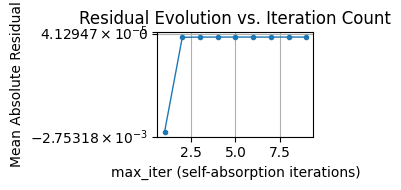

In [134]:
# Set up storage for residuals
residual_evolution = []

# Loop over max_iter from 1 to 100
for max_iter in range(1, 10):
    specdust, mdust, residual = compute_dust_emission(
        duste_gamma=1,
        csp_wave=csp.wave,
        spec_diffuse=spec_diffuse,
        spec_dustfree=spec_dustfree,
        dustem2_dustem=dustem2_dustem,
        spec_fsps_emission=spec_fsps_hot_dust_emi,
        max_iter=max_iter,
        return_residual=True
    )
    print('max_iter:', max_iter, 'residual:', residual)


    residual_evolution.append(residual)

# Plot residual evolution
plt.figure(figsize=(10/3, 2))
plt.plot(np.arange(1, 10), residual_evolution, marker='o', markersize=3, lw=1)
plt.xlabel("max_iter (self-absorption iterations)")
plt.ylabel("Mean Absolute Residual")
plt.title("Residual Evolution vs. Iteration Count")
plt.yscale("symlog")
plt.grid(True)
plt.tight_layout()

print('Final dust mass from custom function:', mdust)
print('Final dust mass from FSPS:', hot_mdust)
plt.savefig('residual_evolution_hot_dust20.png')

Final dust mass from custom function: 17019680.54235366
Final dust mass from FSPS (cold): 17021078.605255414
residual in mdust: -8.213715089255669e-05


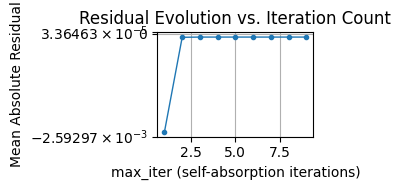

In [135]:
# Set up storage for residuals
residual_evolution = []

# Loop over max_iter from 1 to 100
for max_iter in range(1, 10):
    specdust, mdust, residual = compute_dust_emission(
        duste_gamma=0,
        csp_wave=csp.wave,
        spec_diffuse=spec_diffuse,
        spec_dustfree=spec_dustfree,
        dustem2_dustem=dustem2_dustem,
        spec_fsps_emission=spec_fsps_cold_dust_emi,
        max_iter=max_iter,
        return_residual=True
    )


    residual_evolution.append(residual)

# Plot residual evolution
plt.figure(figsize=(10/3, 2))
plt.plot(np.arange(1, 10), residual_evolution, marker='o', markersize=3, lw=1)
plt.xlabel("max_iter (self-absorption iterations)")
plt.ylabel("Mean Absolute Residual")
plt.title("Residual Evolution vs. Iteration Count")
plt.yscale("symlog")
plt.grid(True)
plt.tight_layout()

print('Final dust mass from custom function:', mdust)
print('Final dust mass from FSPS (cold):', cold_mdust)

print('residual in mdust:', (mdust - cold_mdust) / cold_mdust)
plt.savefig('residual_evolution_cold_dust20.png')

In [136]:
specdust_jax, mdust_jax, tduste_jax = compute_dust_emission_jax(
    sp,
    csp.wave,
    spec_diffuse,
    spec_dustfree,
    dustem2_dustem
)

Lbol before attenuation: -2469577500.0
Lbol after attenuation: -97148890.0


-8.574542e-05


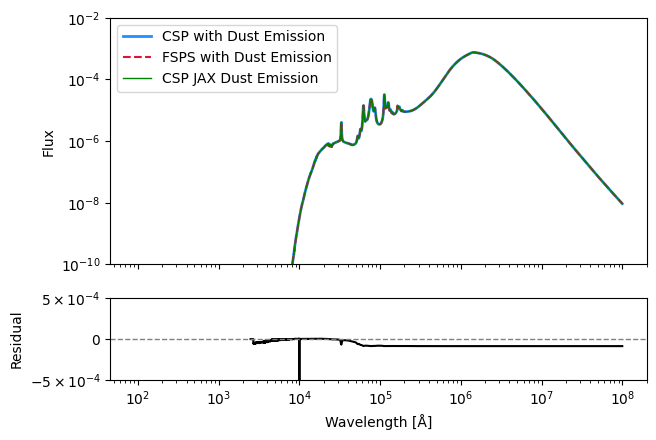

In [137]:

# Compute normalized residuals
residuals = (specdust - spec_fsps_cold_dust_emi) / spec_fsps_cold_dust_emi

# Create figure with two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3, 4.5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Top panel: spectra
ax1.loglog(csp.wave, specdust, color='dodgerblue', lw = 2, label='CSP with Dust Emission')
ax1.loglog(csp.wave, spec_fsps_cold_dust_emi, ls = 'dashed', color='crimson', label='FSPS with Dust Emission')
ax1.loglog(csp.wave, specdust_jax, color='green', lw=1, label='CSP JAX Dust Emission')
ax1.set_ylim(1e-10, 1e-2)

ax1.set_ylabel("Flux")
ax1.legend()

# Bottom panel: normalized residuals
ax2.plot(csp.wave, residuals, color='black')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.set_yscale('symlog')
ax2.set_ylabel("Residual")
ax2.set_xlabel("Wavelength [Å]")
ax2.set_ylim(-0.5*1e-3, 0.5*1e-3)

plt.tight_layout()
print(residuals[-1])

In [120]:
x = wave
y = specdustfree


# Fortran-style TSUM expression
tsum_fortran = np.sum(np.abs(x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)

# NumPy trapezoidal integration
tsum_trapz = np.trapezoid(y, x)

tsum_jnp = jnp.trapezoid(y, x)

print("Fortran-style tsum :", tsum_fortran)
print("np.trapezoid result    :", tsum_trapz)
print("jnp.trapezoid result   :", tsum_jnp)
print("Difference         :", np.abs(tsum_fortran - tsum_trapz)) 

Fortran-style tsum : 0.093742594
np.trapz result    : 0.09374259828024632
jnp.trapz result   : 0.093742594
Difference         : 7.450581e-09
